# SAD Classification (binary): State-Aware MDM

## TLDR

This notebook uses three outer subject-disjoint folds for evaluation. Inside each outer training set, a second three-fold search chooses the MDM covariance metric. The outer test subjects are never used to choose that metric.

## Context & Methods

We ask a simple question: can resting-state EEG distinguish subjects with a recorded social anxiety disorder (SAD) diagnosis from those without one? The second group is not necessarily healthy; its subjects may have other diagnoses. You can run the same binary classifier for another disorder by changing `TARGET` in the parameters cell — for example, `"Depression"`.

We use this pipeline:

4–15 Hz filter → 2 s windows → OAS covariance → per-state mean covariance → state-aware MDM

For each subject, we average window covariances separately for the eyes-open and eyes-closed recordings, then classify with MDM. Balanced accuracy is the selection and evaluation metric. The preprocessing choices are fixed before looking at the labels; the MDM metric is selected in nested, subject-disjoint cross-validation.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score

from pcp_project.classify import (
    StateAwareMDM,
    build_classification_pipeline,
    cross_validate_subjects,
    make_subject_folds,
    nested_search_subjects,
)
from pcp_project.data import (
    binary_target,
    list_subject_ids,
    load_labels,
    load_subject,
)
from pcp_project.plotting import plot_mdm_distances

RANDOM_STATE = 7
N_SPLITS = 3
INNER_SPLITS = 3
MDM_METRICS = ("riemann", "logeuclid")
TARGET = "SAD"  # or "Depression"
TARGET_COLUMNS = {
    "SAD": "SCID5_CV_SAD",
    "Depression": "SCID5_CV_Depression",
}
TARGET_COLUMN = TARGET_COLUMNS[TARGET]

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pcp_project").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = Path(os.environ.get("PCP_DATA_DIR", PROJECT_ROOT / "data" / "data-20260528"))

## Load the full matched cohort

The local dataset contains 44 EEG recordings. SAD and Depression each have 21 recorded and 23 not-recorded subjects.

In [2]:
labels = load_labels(DATA_DIR / "labels_reduced.csv")
subject_ids = [
    subject_id
    for subject_id in list_subject_ids(DATA_DIR)
    if subject_id in labels.index
]
y = binary_target(labels, subject_ids, TARGET_COLUMN)
groups = np.asarray(subject_ids)
target_groups = np.where(y == 1, f"{TARGET} recorded", f"{TARGET} not recorded")

print(f"Matched EEG subjects: {len(subject_ids)}")
pd.Series(target_groups, name="target group").value_counts().to_frame("subjects")

Matched EEG subjects: 44


,subjects
target group,
SAD not recorded,23
SAD recorded,21


## Extract state covariance matrices one subject at a time

Filtering, windowing, OAS covariance, and within-state averaging are fixed subject-local operations. The project pipeline runs those steps and keeps the eyes-open and eyes-closed covariance matrices separate. We process one subject at a time so the full recordings do not have to stay in memory.

We keep the 4–15 Hz band and non-overlapping 2 s windows fixed. At 256 Hz, a window has 512 samples for the 61-channel covariance; this is a practical compromise between covariance support and the number of windows. It is also close to a published resting-state EEG setup using non-overlapping 2 s epochs and sub-bands covering 4–16 Hz ([study](https://www.mdpi.com/2076-3417/13/11/6606)). That precedent does not prove this band is optimal for this cohort, so the notebook states it as a modelling choice rather than a tuned result.

OAS shrinkage is used because each covariance is estimated from a short window in a moderately high-dimensional setting. The estimator was derived for improved covariance estimation when the sample covariance is noisy ([Chen et al., 2010](https://arxiv.org/abs/0907.4698)). These operations are label-free and subject-local, so computing them before the nested split does not share information across subjects.

In [3]:
covariance_extractor = build_classification_pipeline(
    classifier="passthrough",  # extract features only; MDM is fitted later in cross-validation
    window_seconds=2.0,  # long enough for stable per-window covariances
    covariance="oas",  # shrinkage helps when windows are short relative to channel count
    aggregation="stack",  # keep one eyes-open and one eyes-closed matrix per subject
    state_order=(0, 1),  # eyes open, then eyes closed
    feature_transform="identity",  # keep covariance matrices; MDM classifies in matrix space
)

first_subject = load_subject(subject_ids[0], DATA_DIR)
covariance_extractor.fit([first_subject])
covariance_rows = [covariance_extractor.transform([first_subject])[0]]
del first_subject

for subject_id in subject_ids[1:]:
    subject = load_subject(subject_id, DATA_DIR)
    covariance_rows.append(covariance_extractor.transform([subject])[0])
    del subject

subject_state_covariances = np.stack(covariance_rows)

print(f"Subject/state covariance tensor: {subject_state_covariances.shape}")

Subject/state covariance tensor: (44, 2, 61, 61)


### The classifier pipeline

Each subject arrives as two covariance matrices (eyes open and eyes closed). The classifier makes a prediction in two steps:

1. **Minimum Distance to Mean (MDM)** — For each diagnosis group and recording state, we compute a typical covariance matrix. To classify a subject, we measure how far their matrix is from each centroid using geometry suited to positive-definite matrices. Riemannian MDM is an established EEG classifier ([Barachant et al., 2012](https://pubmed.ncbi.nlm.nih.gov/22010143/)). We compare `riemann` with `logeuclid`, another metric supported by the [pyRiemann MDM implementation](https://pyriemann.readthedocs.io/en/latest/generated/pyriemann.classification.MDM.html).
2. **State-aware combination** — We do this separately for eyes open and eyes closed, then combine the two distances with equal weight. The subject is assigned to whichever diagnosis centroid is closer overall.

The MDM model and dummy baseline are evaluated on the same subject-disjoint outer folds. Within each outer training set, `nested_search_subjects` selects the metric on new inner subject folds. This separation matters because selecting parameters and reporting performance on the same folds can bias the estimate ([Cawley & Talbot, 2010](https://www.jmlr.org/papers/v11/cawley10a.html)).

In [4]:
folds = make_subject_folds(
    y,
    groups,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
)
assert all(
    set(groups[train_index]).isdisjoint(groups[test_index])
    for train_index, test_index in folds
)

state_mdm = StateAwareMDM()
state_mdm_scores = nested_search_subjects(
    state_mdm,
    {"metric": MDM_METRICS},
    subject_state_covariances,
    y,
    groups,
    cv=folds,
    inner_splits=INNER_SPLITS,
    scoring="balanced_accuracy",
    n_jobs=1,
)
dummy_scores = cross_validate_subjects(
    DummyClassifier(strategy="most_frequent"),
    np.zeros((len(y), 1)),
    y,
    groups,
    cv=folds,
    scoring="balanced_accuracy",
)

fold_results = pd.DataFrame(
    {
        "outer balanced accuracy": state_mdm_scores["test_score"],
        "best inner balanced accuracy": state_mdm_scores["best_inner_score"],
        "dummy balanced accuracy": dummy_scores["test_score"],
    },
    index=[f"Fold {fold}" for fold in range(1, N_SPLITS + 1)],
)
fold_results["selected metric"] = [
    params["metric"] for params in state_mdm_scores["best_params"]
]
display(fold_results.round(3))

score_columns = [
    "outer balanced accuracy",
    "best inner balanced accuracy",
    "dummy balanced accuracy",
]
fold_results[score_columns].mean().rename("Mean").round(3).to_frame()

,outer balanced accuracy,best inner balanced accuracy,dummy balanced accuracy,selected metric
Fold 1,0.393,0.500,0.5,riemann
Fold 2,0.545,0.492,0.5,riemann
Fold 3,0.643,0.533,0.5,riemann


,Mean
outer balanced accuracy,0.527
best inner balanced accuracy,0.508
dummy balanced accuracy,0.500


## Out-of-fold predictions

Each subject is predicted by a model that did not train on that subject. We keep the two class distances so the decision rule can be plotted directly.

In [5]:
classes = np.unique(y)

oof_distances = np.empty((len(y), len(classes)))
for (_, test_index), fold_mdm in zip(
    folds, state_mdm_scores["estimator"], strict=True
):
    oof_distances[test_index] = fold_mdm.transform(
        subject_state_covariances[test_index]
    )

oof_predictions = classes[np.argmin(oof_distances, axis=1)]
oof_fold_scores = np.asarray(
    [
        balanced_accuracy_score(y[test_index], oof_predictions[test_index])
        for _, test_index in folds
    ]
)
np.testing.assert_allclose(oof_fold_scores, state_mdm_scores["test_score"])

prediction_groups = np.where(
    oof_predictions == 1,
    f"{TARGET} recorded",
    f"{TARGET} not recorded",
)
mdm_confusion = pd.crosstab(
    pd.Series(target_groups, name="Actual"),
    pd.Series(prediction_groups, name="Predicted"),
)

display(mdm_confusion)

Predicted,SAD not recorded,SAD recorded
Actual,,
SAD not recorded,12,11
SAD recorded,10,11


## Fold performance

Each bar is one held-out fold. The dashed line is the most-frequent dummy score.

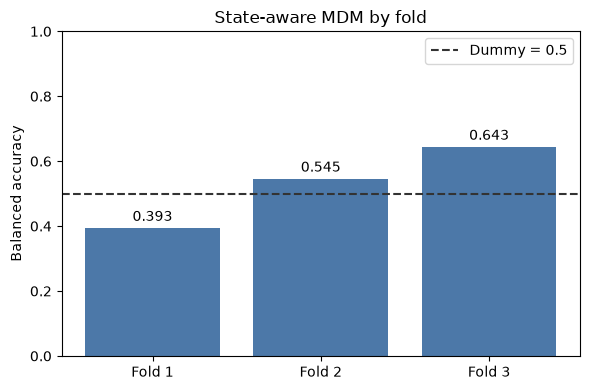

In [6]:
fold_labels = [f"Fold {fold}" for fold in range(1, N_SPLITS + 1)]
fold_scores = state_mdm_scores["test_score"]

figure, axis = plt.subplots(figsize=(6, 4))
bars = axis.bar(fold_labels, fold_scores, color="#4C78A8")
axis.axhline(0.5, color="#333333", linestyle="--", label="Dummy = 0.5")
axis.bar_label(bars, fmt="%.3f", padding=3)
axis.set_ylim(0, 1)
axis.set_ylabel("Balanced accuracy")
axis.set_title("State-aware MDM by fold")
axis.legend()
figure.tight_layout()
figure;

## How the classifier makes a prediction

Each point is a held-out subject, and both recording states are already combined in these distances. The classifier chooses the closer class centroid: points below the dashed line are predicted as recorded, while points above it are predicted as not recorded. Subjects the model misclassifies are marked with an ×.

Centroids differ across folds, so these are comparable held-out decision diagnostics rather than one global embedding.

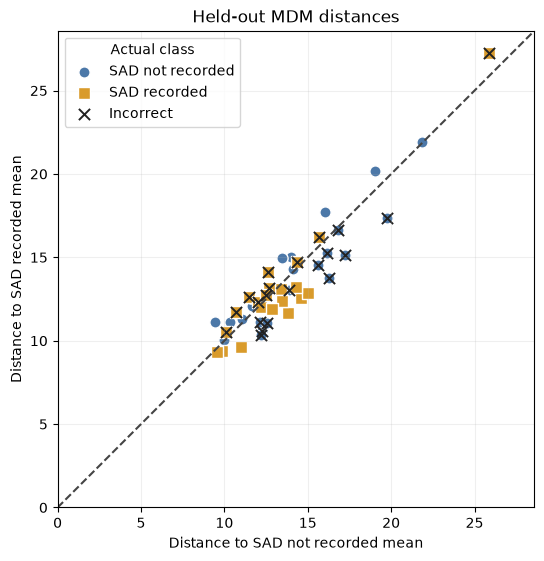

In [7]:
plot_mdm_distances(
    oof_distances,
    y,
    classes=classes,
    class_names=[f"{TARGET} not recorded", f"{TARGET} recorded"],
);

## Takeaways

- The metric shown for a fold was selected using only that fold's training subjects.
- Every outer score and plotted prediction is held out: subjects never appear in both training and test within a fold.
- The most-frequent dummy uses the same outer folds, so it remains a direct baseline.